<a href="https://colab.research.google.com/github/BVNikhil/LibraryMangement/blob/main/U2_MH2_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Problem Statement

Perform customer segmentation using bank data into distinct categories based on their behavioral patterns

## Learning Objectives

At the end of the experiment, you will be able to:

* Understand clustering
* Find groups or clusters using K-means algorithm
* Visualize the high-dimensional data to low-dimensional data (2D) by applying t-SNE algorithm

In [ ]:
#@title  Mini Hackathon Walkthrough
from IPython.display import HTML

HTML("""<video width="854" height="480" controls>
  <source src="https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Walkthrough/Customer_Segmentation.mp4" type="video/mp4">
</video>
""")

## Domain Information

- **Customer segmentation** refers to the process of dividing a set of potential customers into groups (or segments) based on shared attributes, interests, and behaviors.
- One of the key pain points for bank marketing team is to know their customers and identify their needs.
- For this mini-hackathon, we will use the popular **K-Means clustering** algorithm to segment customers based on their behavior from the bank data. The basic concept is that consumers who share common traits would respond to marketing communication in a similar way so that the bank marketing team can reach out to each group in a relevant and effective way.

## Dataset

### Description

The dataset chosen for this mini hackathon is the behavior of customers in the bank for 6 months, this dataset is made up of 13 features.

**Attribute Information**

- **CUSTID:** Identification of Credit Cardholder
- **BALANCE:** Balance amount left in customer's account to make purchases
- **PURCHASES:** Amount of purchases made from the account
- **INSTALLMENTS_PURCHASES:** Amount of purchase done in installment
- **CASH_ADVANCE:** Cash in advance given by the user
- **PURCHASES_FREQUENCY:** How frequently the Purchases are being made score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
- **CASH_ADVANCE_FREQUENCY:** How frequently the cash in advance being paid
- **CASH_ADVANCE_TRX:** Number of Transactions made with "Cash in Advance"
- **CREDIT_LIMIT:** Limit of Credit Card for user
- **PAYMENTS:** Amount of Payment done by a user
- **MINIMUM_PAYMENTS:** Minimum amount of payments made by a user
- **PRC_FULL_PAYMENT:** Percent of full payment paid by a user
- **TENURE:** Tenure of credit card service for user

**Note:** The currency values mentioned above are in "dollars"

## Grading = 10 Marks

## Setup Steps

In [ ]:
#@title Run this cell to complete the setup for this Notebook

from IPython import get_ipython
ipython = get_ipython()

notebook="U2_MH2_Customer_Segmentation" #name of the notebook
Answer = "This notebook is graded by mentors on the day of hackathon"
def setup():
    ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Marketing_data_clustering.csv")
    print ("Setup completed successfully")
    return

setup()

Setup completed successfully


### Importing Required Packages

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

## **Stage 1:** Data Pre-Processing (2 Marks)

- Replace the missing values in any other column appropriately with mean / median / mode.

  Hint: Use pandas [fillna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html) function to replace the missing values

- Perform correlation on the data features and remove highly correlated features from the data
  
  Hint: Use pandas [corr](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html)

- Drop any unwanted columns
  
  Hint: Use pandas [drop](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

- Perform `StandardScaler()` on the data features
  
  Hint: Use Sklearns [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)



In [ ]:
# YOUR CODE HERE
df = pd.read_csv('Marketing_data_clustering.csv')
df.head()

,CUST_ID,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,95.40,95.4,0.00000,0.166667,0.000000,0,1000.0,201.802084,139.509787,0.0,12
1,C10005,817.714335,16.00,0.0,0.00000,0.083333,0.000000,0,1200.0,678.334763,244.791237,0.0,12
2,C10008,1823.652743,436.20,436.2,0.00000,1.000000,0.000000,0,2300.0,679.065082,532.033990,0.0,12
3,C10009,1014.926473,861.49,200.0,0.00000,0.333333,0.000000,0,7000.0,688.278568,311.963409,0.0,12
4,C10015,2772.772734,0.00,0.0,346.81139,0.000000,0.083333,1,3000.0,805.647974,989.962866,0.0,12


In [ ]:
df.shape

(2994, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2994 entries, 0 to 2993
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CUST_ID                 2994 non-null   object 
 1   BALANCE                 2994 non-null   float64
 2   PURCHASES               2994 non-null   float64
 3   INSTALLMENTS_PURCHASES  2994 non-null   float64
 4   CASH_ADVANCE            2994 non-null   float64
 5   PURCHASES_FREQUENCY     2994 non-null   float64
 6   CASH_ADVANCE_FREQUENCY  2994 non-null   float64
 7   CASH_ADVANCE_TRX        2994 non-null   int64  
 8   CREDIT_LIMIT            2994 non-null   float64
 9   PAYMENTS                2994 non-null   float64
 10  MINIMUM_PAYMENTS        2945 non-null   float64
 11  PRC_FULL_PAYMENT        2994 non-null   float64
 12  TENURE                  2994 non-null   int64  
dtypes: float64(10), int64(2), object(1)
memory usage: 304.2+ KB


In [ ]:
print(df['MINIMUM_PAYMENTS'].isna().sum())

49


In [ ]:
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean(), inplace=True)

/tmp/ipython-input-1863628565.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean(), inplace=True)


In [ ]:
df_co = df.drop(columns = 'CUST_ID')
df_co.corr()

,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,-0.034273,-0.108315,0.368653,-0.205498,0.346867,0.319499,0.318990,0.206895,0.768832,-0.359114,NaN
PURCHASES,-0.034273,1.000000,0.669130,-0.204737,0.604114,-0.256953,-0.222998,0.210281,0.209721,0.013705,0.089057,NaN
INSTALLMENTS_PURCHASES,-0.108315,0.669130,1.000000,-0.190027,0.733458,-0.254217,-0.228237,0.086503,0.119167,0.011561,0.153122,NaN
CASH_ADVANCE,0.368653,-0.204737,-0.190027,1.000000,-0.309937,0.643990,0.682928,0.082986,0.323777,0.213419,-0.038101,NaN
PURCHASES_FREQUENCY,-0.205498,0.604114,0.733458,-0.309937,1.000000,-0.376825,-0.332471,0.033842,0.014541,-0.045405,0.203014,NaN
CASH_ADVANCE_FREQUENCY,0.346867,-0.256953,-0.254217,0.643990,-0.376825,1.000000,0.910790,-0.043460,0.173395,0.217509,-0.116330,NaN
CASH_ADVANCE_TRX,0.319499,-0.222998,-0.228237,0.682928,-0.332471,0.910790,1.000000,-0.044277,0.183596,0.222655,-0.106766,NaN
CREDIT_LIMIT,0.318990,0.210281,0.086503,0.082986,0.033842,-0.043460,-0.044277,1.000000,0.191864,0.108112,0.011315,NaN
PAYMENTS,0.206895,0.209721,0.119167,0.323777,0.014541,0.173395,0.183596,0.191864,1.000000,0.163339,0.159018,NaN
MINIMUM_PAYMENTS,0.768832,0.013705,0.011561,0.213419,-0.045405,0.217509,0.222655,0.108112,0.163339,1.000000,-0.297843,NaN


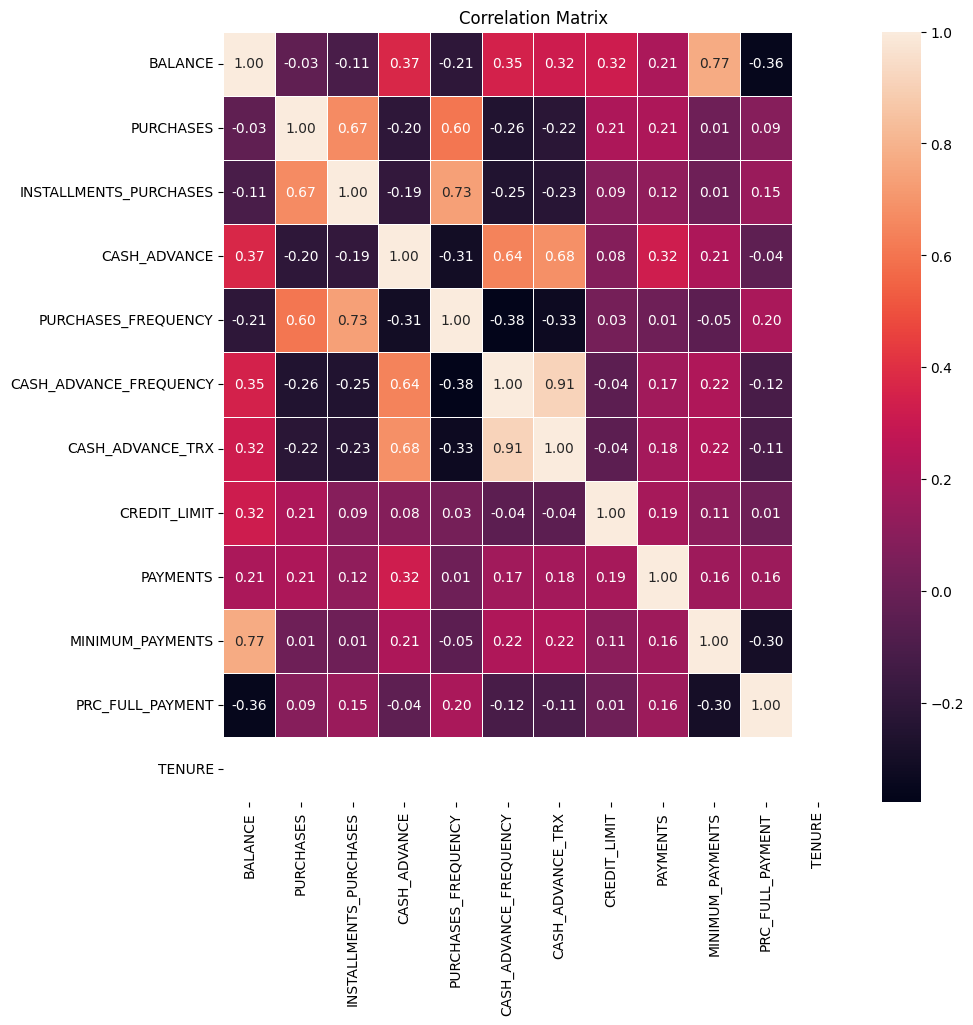

In [ ]:
plt.figure(figsize=(10,10))
plt.title('Correlation Matrix')
sns.heatmap(df_co.corr(), annot=True,linewidths=0.5,fmt='.2f')
plt.show()

In [ ]:
print(df['TENURE'].unique())

[12]


In [ ]:
df_co.drop(columns = ['TENURE'], inplace=True)

In [ ]:
corr_matrix = df_co.corr()
corr_matrix

,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
BALANCE,1.000000,-0.034273,-0.108315,0.368653,-0.205498,0.346867,0.319499,0.318990,0.206895,0.768832,-0.359114
PURCHASES,-0.034273,1.000000,0.669130,-0.204737,0.604114,-0.256953,-0.222998,0.210281,0.209721,0.013705,0.089057
INSTALLMENTS_PURCHASES,-0.108315,0.669130,1.000000,-0.190027,0.733458,-0.254217,-0.228237,0.086503,0.119167,0.011561,0.153122
CASH_ADVANCE,0.368653,-0.204737,-0.190027,1.000000,-0.309937,0.643990,0.682928,0.082986,0.323777,0.213419,-0.038101
PURCHASES_FREQUENCY,-0.205498,0.604114,0.733458,-0.309937,1.000000,-0.376825,-0.332471,0.033842,0.014541,-0.045405,0.203014
CASH_ADVANCE_FREQUENCY,0.346867,-0.256953,-0.254217,0.643990,-0.376825,1.000000,0.910790,-0.043460,0.173395,0.217509,-0.116330
CASH_ADVANCE_TRX,0.319499,-0.222998,-0.228237,0.682928,-0.332471,0.910790,1.000000,-0.044277,0.183596,0.222655,-0.106766
CREDIT_LIMIT,0.318990,0.210281,0.086503,0.082986,0.033842,-0.043460,-0.044277,1.000000,0.191864,0.108112,0.011315
PAYMENTS,0.206895,0.209721,0.119167,0.323777,0.014541,0.173395,0.183596,0.191864,1.000000,0.163339,0.159018
MINIMUM_PAYMENTS,0.768832,0.013705,0.011561,0.213419,-0.045405,0.217509,0.222655,0.108112,0.163339,1.000000,-0.297843


In [ ]:
to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8: # Threshold for high correlation
            colname = corr_matrix.columns[i]
            to_drop.add(colname)

print(f"Features to be removed due to high correlation: {list(to_drop)}")

Features to be removed due to high correlation: ['CASH_ADVANCE_TRX']


In [ ]:
df_co_cleaned = df_co.drop(columns=list(to_drop))
print(f"Original df_co shape: {df_co.shape}")
print(f"New df_co_cleaned shape after dropping columns: {df_co_cleaned.shape}")

Original df_co shape: (2994, 11)
New df_co_cleaned shape after dropping columns: (2994, 10)


In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_co_cleaned)
df_scaled = pd.DataFrame(df_scaled, columns=df_co_cleaned.columns)

#Data scaled using StandardScaler and stored in 'df_scaled'
df_scaled.head()

,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
0,-1.133600,-0.632613,-0.317151,-0.641837,-0.605044,-0.795323,-0.904793,-0.881709,-0.943177,-0.414442
1,-0.376303,-0.811660,-0.689393,-0.641837,-0.828798,-0.795323,-0.822240,-0.197005,-0.642098,-0.414442
2,0.604361,0.135888,1.012616,-0.641837,1.632485,-0.795323,-0.368198,-0.195955,0.179348,-0.414442
3,-0.184046,1.094914,0.090987,-0.641837,-0.157540,-0.795323,1.571799,-0.182717,-0.450001,-0.414442
4,1.529635,-0.847739,-0.689393,-0.108188,-1.052550,-0.142048,-0.079263,-0.014075,1.488914,-0.414442


## **Stage 2:** K Means (3 Marks)

- Find the right number of clusters to be chosen using the elbow method
  
- Perform K-Means on the chosen optimal number of clusters

  **Hint:** Refer to this [link](https://towardsdatascience.com/clustering-algorithms-for-customer-segmentation-af637c6830ac) for finding the k-clusters using elbow method and applying kmeans

In [ ]:
# YOUR CODE HERE
#Testing Values for K from 1 to 10
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    print("wcss value at k = ",i,"is",kmeans.inertia_)

wcss value at k =  1 is 29939.999999999978
wcss value at k =  2 is 23696.6232013964
wcss value at k =  3 is 20286.52538256383
wcss value at k =  4 is 18205.161772937467
wcss value at k =  5 is 16561.535869034647
wcss value at k =  6 is 15280.919614099199
wcss value at k =  7 is 14280.292741799585
wcss value at k =  8 is 13432.164008174987
wcss value at k =  9 is 12666.443130975527
wcss value at k =  10 is 12110.012785809173


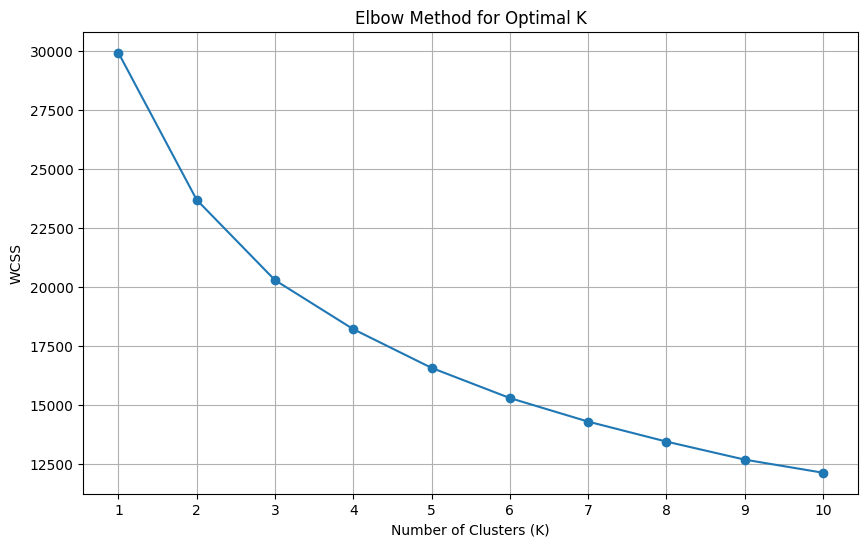

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 4 # Based on observing the elbow plot, k=4 appears to be a reasonable elbow point

kmeans_optimal = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans_optimal.fit(df_scaled)
df_scaled['Cluster'] = kmeans_optimal.labels_

df_scaled.head()

,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,Cluster
0,-1.133600,-0.632613,-0.317151,-0.641837,-0.605044,-0.795323,-0.904793,-0.881709,-0.943177,-0.414442,1
1,-0.376303,-0.811660,-0.689393,-0.641837,-0.828798,-0.795323,-0.822240,-0.197005,-0.642098,-0.414442,1
2,0.604361,0.135888,1.012616,-0.641837,1.632485,-0.795323,-0.368198,-0.195955,0.179348,-0.414442,0
3,-0.184046,1.094914,0.090987,-0.641837,-0.157540,-0.795323,1.571799,-0.182717,-0.450001,-0.414442,0
4,1.529635,-0.847739,-0.689393,-0.108188,-1.052550,-0.142048,-0.079263,-0.014075,1.488914,-0.414442,2


## **Stage 3:** Apply **TSNE** with 2 components (n_components = 2) and visualize the clusters (3 Marks)

Hint: Use Sklearns [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

**Note:** Produce a visualization with distinctly isolated clusters and It is not necessary to plot the centroids



In [ ]:
# YOUR CODE HERE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_features = tsne.fit_transform(df_scaled.drop(columns=['Cluster']))
df_tsne = pd.DataFrame(data=tsne_features, columns=['TSNE1', 'TSNE2'])
df_tsne['Cluster'] = df_scaled['Cluster']
print("t-SNE dimensionality reduction completed and results stored in 'df_tsne'.")
df_tsne.head()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE dimensionality reduction completed and results stored in 'df_tsne'.


,TSNE1,TSNE2,Cluster
0,22.504660,-28.284945,1
1,1.081476,-15.022244,1
2,11.088199,24.921307,0
3,14.925607,6.353316,0
4,-27.045986,21.100416,2


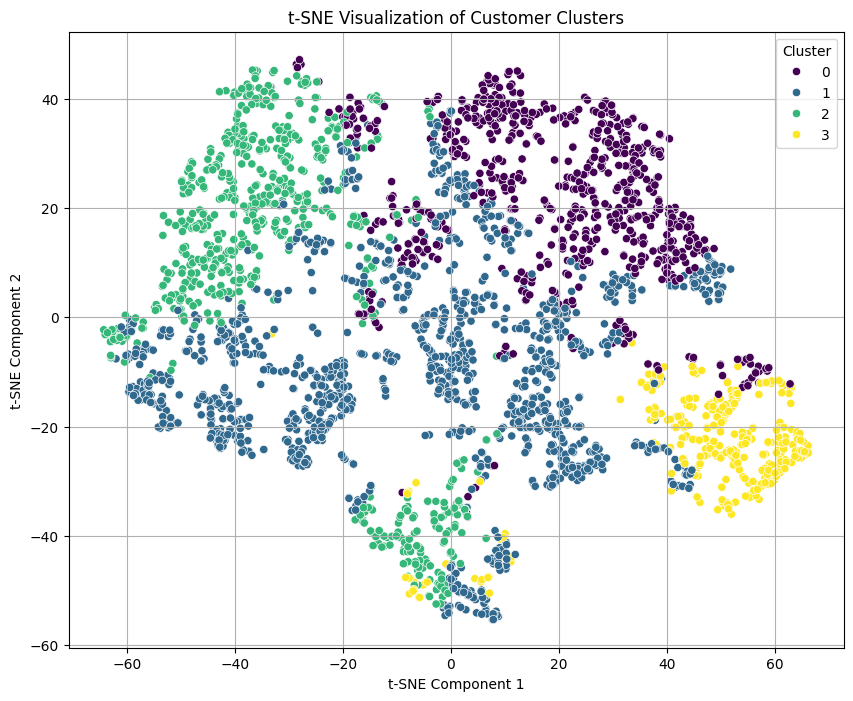

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=df_tsne, palette='viridis', legend='full')
plt.title('t-SNE Visualization of Customer Clusters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

## **Stage 4:** Insights for each cluster

#### **Stage 4(a)** (1 Mark):
- To understand the behavior of the customers from each cluster print the respective centroid point values obtained from the scaled dataframe
- Get the original representation of the scaled centroid points using [inverse_transformation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.inverse_transform) technique

In [ ]:
cluster_centroids_scaled = kmeans_optimal.cluster_centers_
cluster_centroids_original = scaler.inverse_transform(cluster_centroids_scaled[:, :-1]) # Exclude the last column (Cluster)
df_centroids = pd.DataFrame(cluster_centroids_original, columns=df_co_cleaned.columns)
print("Scaled cluster centroids:\n", cluster_centroids_scaled)
print("\nOriginal scale cluster centroids:\n")
df_centroids

Scaled cluster centroids:
 [[-1.40134643e-02  1.10503283e+00  1.21348661e+00 -3.84960805e-01
   1.12158211e+00 -4.48723122e-01  1.67211058e-01  2.43141877e-01
   1.92081160e-01 -2.82557072e-01 -7.77156117e-15]
 [-3.13593248e-01 -4.24014354e-01 -4.98760558e-01 -3.31875282e-01
  -4.60314234e-01 -1.73346344e-01 -3.24848333e-01 -4.29923385e-01
  -3.14522662e-01 -2.89559608e-01  3.00000000e+00]
 [ 1.06744154e+00 -4.90054947e-01 -5.37829153e-01  1.21565203e+00
  -6.72368513e-01  1.04214157e+00  3.95722069e-01  5.66346007e-01
   7.82188660e-01 -2.43841642e-01  1.00000000e+00]
 [-1.01935764e+00  2.82477462e-01  4.51436988e-01 -3.89383051e-01
   8.07858780e-01 -5.27089968e-01  1.04841783e-01 -9.01948136e-03
  -8.66324576e-01  2.46177436e+00  2.00000000e+00]]

Original scale cluster centroids:



,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
0,1189.341069,865.977417,487.680125,166.940132,0.809722,0.044213,3597.127525,984.662997,536.486625,0.009034
1,882.040483,187.905363,48.856206,201.439701,0.220569,0.079341,2405.023184,516.230701,359.337528,0.008554
2,2298.667448,158.618968,38.843496,1207.156945,0.141593,0.234390,4150.737463,1209.602927,742.835266,0.011686
3,158.087055,501.206589,292.377947,164.066174,0.692881,0.034216,3446.026490,809.166607,166.383575,0.197020


#### **Stage 4(b)** (1 Mark):
- Report your observations in the form of text, about the customers based on the centroid points

Hint: If require use [clustermap](https://seaborn.pydata.org/generated/seaborn.clustermap.html)

In [ ]:
for i in df_centroids:
  print(i)
  k=0
  for j in df_centroids[i]:
    print(k,"th Cluster : ",j)
    k=k+1
  print()

BALANCE
0 th Cluster :  1189.3410692375
1 th Cluster :  882.0404833500772
2 th Cluster :  2298.6674484439513
3 th Cluster :  158.08705494370838

PURCHASES
0 th Cluster :  865.9774166666662
1 th Cluster :  187.90536321483748
2 th Cluster :  158.61896755162306
3 th Cluster :  501.20658940397345

INSTALLMENTS_PURCHASES
0 th Cluster :  487.6801250000003
1 th Cluster :  48.856205564144204
2 th Cluster :  38.84349557522299
3 th Cluster :  292.37794701986746

CASH_ADVANCE
0 th Cluster :  166.94013203333134
1 th Cluster :  201.43970114760302
2 th Cluster :  1207.1569452890858
3 th Cluster :  164.06617357946945

PURCHASES_FREQUENCY
0 th Cluster :  0.809722229166669
1 th Cluster :  0.22056925579597988
2 th Cluster :  0.14159289970501288
3 th Cluster :  0.6928807980132445

CASH_ADVANCE_FREQUENCY
0 th Cluster :  0.04421294166666672
1 th Cluster :  0.07934050386398803
2 th Cluster :  0.23439035103244926
3 th Cluster :  0.034216324503311246

CREDIT_LIMIT
0 th Cluster :  3597.127525252777
1 th Cluste

In [ ]:
for i in zip(df.columns, df_centroids.iloc[0]):
  print(i)

('CUST_ID', 1189.3410692375)
('BALANCE', 865.9774166666662)
('PURCHASES', 487.6801250000003)
('INSTALLMENTS_PURCHASES', 166.94013203333134)
('CASH_ADVANCE', 0.809722229166669)
('PURCHASES_FREQUENCY', 0.04421294166666672)
('CASH_ADVANCE_FREQUENCY', 3597.127525252777)
('CASH_ADVANCE_TRX', 984.6629971402778)
('CREDIT_LIMIT', 536.4866246373114)
('PAYMENTS', 0.009034063888888819)


**Observations:**

Cluster 0 (Low Spenders with Average Balance): Infrequent credit card users, low purchases, low credit limit, mostly make minimum payments.


Cluster 1 (Regular Purchasers/High Spenders): High purchasing activity, especially in installments, rarely use cash advances, carry balances.


Cluster 2 (Conscientious Low Spenders with High Full Payment Ratio): Low balances, moderate purchases with high frequency, responsible users who pay off a significant portion of their debt.


Cluster 3 (High Balance & Cash Advance Users): Highest balances, primary use is cash advances, very low purchases, consistently carry large balances.

Cluster 0 - Low Spenders with Average Balance:

Balance: Moderate (~882)
Purchases: Very low (~188)
Installment Purchases: Very low (~49)
Cash Advance: Low (~201)
Purchases Frequency: Very low (~0.22)
Cash Advance Frequency: Very low (~0.08)
Credit Limit: Low (~2405)
Payments: Low (~516)
Minimum Payments: Low (~359)
Full Payment Ratio: Very low (~0.008)
Observation: These customers maintain an average balance but make very few purchases of any kind. They rarely take cash advances and have a low credit limit. They mostly pay the minimum payment and rarely pay in full. They appear to be cautious or infrequent users of their credit cards for purchases, possibly using them mainly for emergencies or small transactions. They are not active spenders or consistent full payers.
Cluster 1 - Regular Purchasers/High Spenders:

Balance: Average (~1189)
Purchases: High (~866)
Installment Purchases: High (~488)
Cash Advance: Low (~167)
Purchases Frequency: High (~0.81)
Cash Advance Frequency: Very low (~0.04)
Credit Limit: Moderate (~3597)
Payments: Moderate (~985)
Minimum Payments: Moderate (~536)
Full Payment Ratio: Very low (~0.009)
Observation: This group shows high purchasing activity, both overall and for installment purchases, with high purchase frequency. They rarely use cash advances. Their balance, credit limit, and payments are moderate to high. While they spend frequently, they tend to carry balances, indicated by a very low full payment ratio, similar to Cluster 0. They are active consumers utilizing their credit for purchases.
Cluster 2 - Conscientious Low Spenders with High Full Payment Ratio:

Balance: Very low (~158)
Purchases: Moderate (~501)
Installment Purchases: Moderate (~292)
Cash Advance: Low (~164)
Purchases Frequency: High (~0.69)
Cash Advance Frequency: Very low (~0.03)
Credit Limit: Moderate (~3446)
Payments: Moderate (~809)
Minimum Payments: Very low (~166)
Full Payment Ratio: High (~0.197)
Observation: These customers have the lowest balance among all clusters and a significantly higher percentage of full payments. They make moderate purchases with high frequency, but avoid cash advances. Their credit limit is moderate, and they make moderate payments. This cluster represents responsible users who manage their credit well, paying off a substantial portion of their balance regularly and keeping their outstanding debt low.
Cluster 3 - High Balance & Cash Advance Users:

Balance: High (~2299)
Purchases: Very low (~159)
Installment Purchases: Very low (~39)
Cash Advance: Very high (~1207)
Purchases Frequency: Very low (~0.14)
Cash Advance Frequency: High (~0.23)
Credit Limit: High (~4151)
Payments: High (~1210)
Minimum Payments: High (~743)
Full Payment Ratio: Very low (~0.012)
Observation: This cluster is characterized by the highest balances and a very high amount and frequency of cash advances. Their purchases are very low, suggesting they use their card primarily for cash access rather than direct purchases. They have high credit limits and make high payments, but similar to Clusters 0 and 1, their full payment ratio is very low, implying they consistently carry large balances. This group likely relies on credit cards for short-term liquidity or to cover expenses, often accumulating interest due to high outstanding balances.